# IMPORTING PACKAGES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')


In [2]:
#READ THE DATASET
df=pd.read_csv(r"../input/titanic/train.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
#DROPPING A FEW FEATURES TO MAKE IT EASIER TO ANALYZE THE DATA
#AND DEMONSTRATE THE CAPABILITIES OF THE PIVOT_TABLE FUNCTION:

df.drop(['PassengerId','Ticket','Name'],inplace=True,axis=1)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


# BUILDING A PIVOT TABLE USING PANDAS

Time to build a pivot table in python using the awesome Pandas library! We will explore the different facets of a
pivot table in this article and build an awsome.

How to group data using index in a pivot table? pivot_table requires a data and index parameter dats is the pandas
dataframe you pass to the function index is the feature that allows you to group your data. The index feature will appear as an index in the resultant table I will be using the 'sex' column as the index for now

In [4]:
# A SINGLE INDEX(SEX)

table=pd.pivot_table(data=df,index=['Sex'])
print(table)

              Age       Fare     Parch    Pclass     SibSp  Survived
Sex                                                                 
female  27.915709  44.479818  0.649682  2.159236  0.694268  0.742038
male    30.726645  25.523893  0.235702  2.389948  0.429809  0.188908


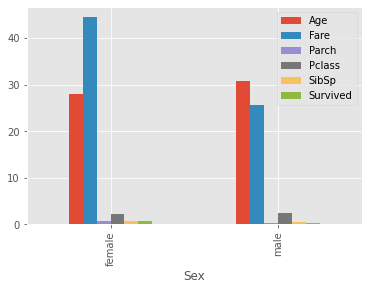

In [5]:
#PLOTTING THE FINDINGS

table.plot(kind='bar');

In [6]:
# A SINGLE INDEX

table=pd.pivot_table(data=df,index=['Embarked'])
print(table)

                Age       Fare     Parch    Pclass     SibSp  Survived
Embarked                                                              
C         30.814769  59.954144  0.363095  1.886905  0.386905  0.553571
Q         28.089286  13.276030  0.168831  2.909091  0.428571  0.389610
S         29.445397  27.079812  0.413043  2.350932  0.571429  0.336957


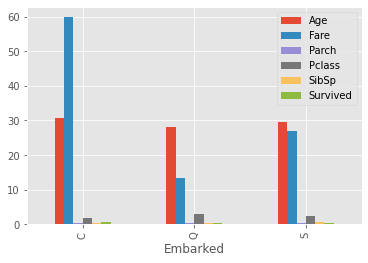

In [7]:
# PLOTTING

table.plot(kind='bar');

In [8]:
# WE CAN ALSO USE MORE THAN ONE INDEX TO GROUP OUR DATA
# PIVOT WITH A MULTI-INDEX

In [9]:
# MULTIPLE INDEXES

table=pd.pivot_table(df,index=['Sex','Pclass'])
print(table)

                     Age        Fare     Parch     SibSp  Survived
Sex    Pclass                                                     
female 1       34.611765  106.125798  0.457447  0.553191  0.968085
       2       28.722973   21.970121  0.605263  0.486842  0.921053
       3       21.750000   16.118810  0.798611  0.895833  0.500000
male   1       41.281386   67.226127  0.278689  0.311475  0.368852
       2       30.740707   19.741782  0.222222  0.342593  0.157407
       3       26.507589   12.661633  0.224784  0.498559  0.135447


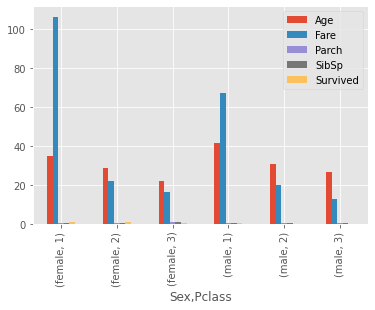

In [10]:
table.plot(kind='bar');


# DIFFERENT AGGREGATE FUNCTION FOR DIFFERENT FEATURES

 The values shown in the table are the result of the summarization that aggfun applies to the feature data aggfunc is 
an aggregate function that pivot_table applies to your grouped data.

By default it is np.mean(), but you can use different aggregate functions for different features too! Just provide a dictionary as an input to the aggfunc parameter with the feature name as the key and the corresponding aggregate function as the value.

I will be using np.mean() for the Age feature and np.sum() for the Survived feature:

In [11]:
#DIFFERENT AGGREGATE FUNCTIONS

table=pd.pivot_table(df,index=['Sex','Pclass'],values=['Survived'],aggfunc=np.mean)
print(table)

               Survived
Sex    Pclass          
female 1       0.968085
       2       0.921053
       3       0.500000
male   1       0.368852
       2       0.157407
       3       0.135447


<AxesSubplot:xlabel='Sex,Pclass'>

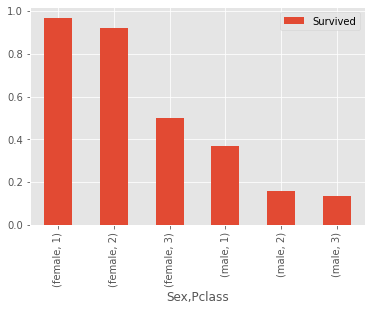

In [12]:
table.plot(kind='bar')

#  FIND THE RELATIONSHIP BETWEEN FEATURES WITH COLUMNS  PARAMETER

Using multiple features as indexes is fine, but using some features as columns will help you to intuitively understand
the relationship between them Also the resultant table can always be better viewed by incorporating the columns parameter of the pivot_table.



In [13]:
#COLUMNS

table=pd.pivot_table(df,index=['Sex'],columns=['Pclass'],values=['Survived'],aggfunc=np.sum)
print(table)

       Survived        
Pclass        1   2   3
Sex                    
female       91  70  72
male         45  17  47


<AxesSubplot:xlabel='Sex'>

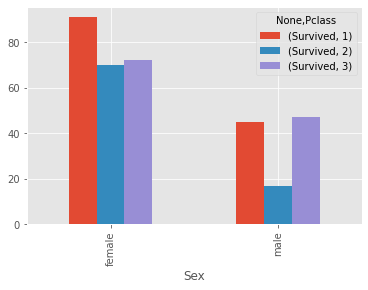

In [14]:
table.plot(kind='bar')

# HANDLING MISSING DATA

In [15]:
# DISPLAY NULL VALUES.

table=pd.pivot_table(df,index=['Sex','Survived','Pclass'],columns=['Embarked'],values=['Age'],aggfunc=np.mean)
print(table)

                              Age                      
Embarked                        C          Q          S
Sex    Survived Pclass                                 
female 0        1       50.000000        NaN  13.500000
                2             NaN        NaN  36.000000
                3       20.700000  28.100000  23.688889
       1        1       35.675676  33.000000  33.619048
                2       19.142857  30.000000  29.091667
                3       11.045455  17.600000  22.548387
male   0        1       43.050000  44.000000  45.362500
                2       29.500000  57.000000  33.414474
                3       27.555556  28.076923  27.168478
       1        1       36.437500        NaN  36.121667
                2        1.000000        NaN  17.095000
                3       18.488571  29.000000  22.933333


In [16]:
# HANDLING NULL VALUES

table=pd.pivot_table(df,index=['Sex','Survived','Pclass'],columns=['Embarked'],values=['Age'],aggfunc=np.mean,fill_value=np.mean(df['Age']))
print(table)


                              Age                      
Embarked                        C          Q          S
Sex    Survived Pclass                                 
female 0        1       50.000000  29.699118  13.500000
                2       29.699118  29.699118  36.000000
                3       20.700000  28.100000  23.688889
       1        1       35.675676  33.000000  33.619048
                2       19.142857  30.000000  29.091667
                3       11.045455  17.600000  22.548387
male   0        1       43.050000  44.000000  45.362500
                2       29.500000  57.000000  33.414474
                3       27.555556  28.076923  27.168478
       1        1       36.437500  29.699118  36.121667
                2        1.000000  29.699118  17.095000
                3       18.488571  29.000000  22.933333


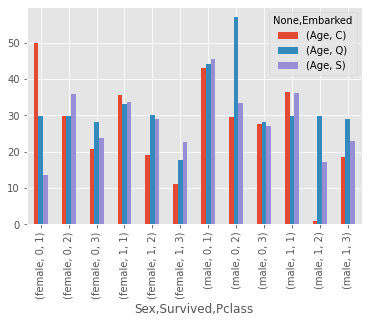

In [17]:
table.plot(kind='bar');